In [20]:
from __future__ import absolute_import, division, print_function, unicode_literals, annotations
import torch
from torchvision.transforms import ToTensor
import numpy as np
from art.defences.preprocessor.preprocessor import Preprocessor
from art.defences.preprocessor import TotalVarMin
import matplotlib.pyplot as plt

import logging
from typing import TYPE_CHECKING

import numpy as np

from art.defences.preprocessor.preprocessor import PreprocessorPyTorch

if TYPE_CHECKING:

    import torch
    from art.utils import CLIP_VALUES_TYPE

from tqdm.auto import tqdm

In [2]:
img_path = "panda.jpg"
img = plt.imread(img_path)

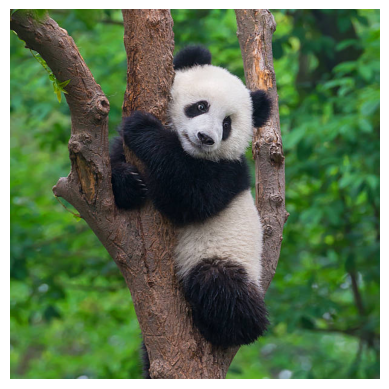

In [3]:
plt.imshow(img)
plt.axis('off')
plt.show()

In [4]:
x_tensor = ToTensor()(img.copy()).transpose(0, 2).unsqueeze(0)
print("Image shape:", x_tensor.shape)

Image shape: torch.Size([1, 612, 612, 3])


In [5]:
x_array = img / 255.0
x_array = np.expand_dims(x_array, axis=0)
print("Image array shape:", x_array.shape)

Image array shape: (1, 612, 612, 3)


In [16]:
class TotalVarMin(Preprocessor):
    """
    Implement the total variance minimization defence.

    | Paper link: https://openreview.net/forum?id=SyJ7ClWCb

    | Please keep in mind the limitations of defences. For more information on the limitations of this
        defence, see https://arxiv.org/abs/1802.00420 . For details on how to evaluate classifier security in general,
        see https://arxiv.org/abs/1902.06705
    """

    params = ["prob", "norm", "lamb", "solver", "max_iter", "clip_values", "verbose"]

    def __init__(
        self,
        prob: float = 0.3,
        norm: int = 2,
        lamb: float = 0.5,
        solver: str = "L-BFGS-B",
        max_iter: int = 10,
        clip_values: "CLIP_VALUES_TYPE" | None = None,
        apply_fit: bool = False,
        apply_predict: bool = True,
        verbose: bool = False,
    ):
        """
        Create an instance of total variance minimization.

        :param prob: Probability of the Bernoulli distribution.
        :param norm: The norm (positive integer).
        :param lamb: The lambda parameter in the objective function.
        :param solver: Current support: `L-BFGS-B`, `CG`, `Newton-CG`.
        :param max_iter: Maximum number of iterations when performing optimization.
        :param clip_values: Tuple of the form `(min, max)` representing the minimum and maximum values allowed
               for features.
        :param apply_fit: True if applied during fitting/training.
        :param apply_predict: True if applied during predicting.
        :param verbose: Show progress bars.
        """
        super().__init__(is_fitted=True, apply_fit=apply_fit, apply_predict=apply_predict)
        self.prob = prob
        self.norm = norm
        self.lamb = lamb
        self.solver = solver
        self.max_iter = max_iter
        self.clip_values = clip_values
        self.verbose = verbose
        self._check_params()

    def __call__(self, x: np.ndarray, y: np.ndarray | None = None) -> tuple[np.ndarray, np.ndarray | None]:
        """
        Apply total variance minimization to sample `x`.

        :param x: Sample to compress with shape `(batch_size, width, height, depth)`.
        :param y: Labels of the sample `x`. This function does not affect them in any way.
        :return: Similar samples.
        """
        if len(x.shape) == 2:
            raise ValueError(
                "Feature vectors detected. Variance minimization can only be applied to data with spatial dimensions."
            )
        x_preproc = x.copy()

        # Minimize one input at a time
        for i, x_i in enumerate(tqdm(x_preproc, desc="Variance minimization", disable=not self.verbose)):
            mask = (np.random.rand(*x_i.shape) < self.prob).astype("int")
            x_preproc[i] = self._minimize(x_i, mask)

        if self.clip_values is not None:
            np.clip(x_preproc, self.clip_values[0], self.clip_values[1], out=x_preproc)

        return x_preproc.astype(ART_NUMPY_DTYPE), y

    def _minimize(self, x: np.ndarray, mask: np.ndarray) -> np.ndarray:
        """
        Minimize the total variance objective function.

        :param x: Original image.
        :param mask: A matrix that decides which points are kept.
        :return: A new image.
        """
        z_min = x.copy()

        for i in range(x.shape[2]):
            res = minimize(
                self._loss_func,
                z_min[:, :, i].flatten(),
                (x[:, :, i], mask[:, :, i], self.norm, self.lamb),
                method=self.solver,
                jac=self._deri_loss_func,
                options={"maxiter": self.max_iter},
            )
            z_min[:, :, i] = np.reshape(res.x, z_min[:, :, i].shape)

        return z_min

    @staticmethod
    def _loss_func(z_init: np.ndarray, x: np.ndarray, mask: np.ndarray, norm: int, lamb: float) -> float:
        """
        Loss function to be minimized.

        :param z_init: Initial guess.
        :param x: Original image.
        :param mask: A matrix that decides which points are kept.
        :param norm: The norm (positive integer).
        :param lamb: The lambda parameter in the objective function.
        :return: Loss value.
        """
        res = np.sqrt(np.power(z_init - x.flatten(), 2).dot(mask.flatten()))
        z_init = np.reshape(z_init, x.shape)
        res += lamb * np.linalg.norm(z_init[1:, :] - z_init[:-1, :], norm, axis=1).sum()
        res += lamb * np.linalg.norm(z_init[:, 1:] - z_init[:, :-1], norm, axis=0).sum()

        return res

    @staticmethod
    def _deri_loss_func(z_init: np.ndarray, x: np.ndarray, mask: np.ndarray, norm: int, lamb: float) -> float:
        """
        Derivative of loss function to be minimized.

        :param z_init: Initial guess.
        :param x: Original image.
        :param mask: A matrix that decides which points are kept.
        :param norm: The norm (positive integer).
        :param lamb: The lambda parameter in the objective function.
        :return: Derivative value.
        """
        # First compute the derivative of the first component of the loss function
        nor1 = np.sqrt(np.power(z_init - x.flatten(), 2).dot(mask.flatten()))
        nor1 = max(nor1, 1e-06)
        der1 = ((z_init - x.flatten()) * mask.flatten()) / (nor1 * 1.0)

        # Then compute the derivative of the second component of the loss function
        z_init = np.reshape(z_init, x.shape)

        if norm == 1:
            z_d1 = np.sign(z_init[1:, :] - z_init[:-1, :])
            z_d2 = np.sign(z_init[:, 1:] - z_init[:, :-1])
        else:
            z_d1_norm = np.power(np.linalg.norm(z_init[1:, :] - z_init[:-1, :], norm, axis=1), norm - 1)
            z_d2_norm = np.power(np.linalg.norm(z_init[:, 1:] - z_init[:, :-1], norm, axis=0), norm - 1)
            z_d1_norm[z_d1_norm < 1e-6] = 1e-6
            z_d2_norm[z_d2_norm < 1e-6] = 1e-6
            z_d1_norm = np.repeat(z_d1_norm[:, np.newaxis], z_init.shape[1], axis=1)
            z_d2_norm = np.repeat(z_d2_norm[np.newaxis, :], z_init.shape[0], axis=0)
            z_d1 = norm * np.power(z_init[1:, :] - z_init[:-1, :], norm - 1) / z_d1_norm
            z_d2 = norm * np.power(z_init[:, 1:] - z_init[:, :-1], norm - 1) / z_d2_norm

        der2 = np.zeros(z_init.shape)
        der2[:-1, :] -= z_d1
        der2[1:, :] += z_d1
        der2[:, :-1] -= z_d2
        der2[:, 1:] += z_d2
        der2 = lamb * der2.flatten()

        # Total derivative
        return der1 + der2

    def _check_params(self) -> None:
        if not isinstance(self.prob, (float, int)) or self.prob < 0.0 or self.prob > 1.0:
            logger.error("Probability must be between 0 and 1.")
            raise ValueError("Probability must be between 0 and 1.")

        if not isinstance(self.norm, int) or self.norm <= 0:
            logger.error("Norm must be a positive integer.")
            raise ValueError("Norm must be a positive integer.")

        if self.solver not in ("L-BFGS-B", "CG", "Newton-CG"):
            logger.error("Current support only L-BFGS-B, CG, Newton-CG.")
            raise ValueError("Current support only L-BFGS-B, CG, Newton-CG.")

        if not isinstance(self.max_iter, int) or self.max_iter <= 0:
            logger.error("Number of iterations must be a positive integer.")
            raise ValueError("Number of iterations must be a positive integer.")

        if self.clip_values is not None:

            if len(self.clip_values) != 2:
                raise ValueError("`clip_values` should be a tuple of 2 floats containing the allowed data range.")

            if np.array(self.clip_values[0] >= self.clip_values[1]).any():
                raise ValueError("Invalid `clip_values`: min >= max.")

        if not isinstance(self.verbose, bool):
            raise ValueError("The argument `verbose` has to be of type bool.")

In [251]:
class TotalVarMinPyTorch(PreprocessorPyTorch):

    params = ["prob", "norm", "lamb", "solver", "max_iter", "clip_values", "verbose"]

    def __init__(
        self,
        prob: float = 0.3,
        norm: int = 2,
        lamb: float = 0.5,
        solver: str = "L-BFGS-B",
        max_iter: int = 10,
        clip_values: "CLIP_VALUES_TYPE" | None = None,
        apply_fit: bool = False,
        apply_predict: bool = True,
        verbose: bool = False,
        device_type: str = "gpu",
    ):
        super().__init__(device_type=device_type, apply_fit=apply_fit, apply_predict=apply_predict)
        self.prob = prob
        self.norm = norm
        self.lamb = lamb
        self.solver = solver
        self.max_iter = max_iter
        self.clip_values = clip_values
        self.verbose = verbose
        self._check_params()

    def forward(
        self, x: "torch.Tensor", y: "torch.Tensor" | None = None
    ) -> tuple["torch.Tensor", "torch.Tensor" | None]:
        """
        Apply total variance minimization to sample `x`.

        :param x: Sample to compress with shape `(batch_size, channels, height, width)`.
        :param y: Labels of the sample `x`. This function does not affect them in any way.
        :return: Similar samples.
        """
        if len(x.shape) != 4:
            raise ValueError("Input `x` must be a 4D tensor (batch, width, height, depth).")
        x_preproc = x.clone()

        # Minimize one input at a time
        for i in tqdm(range(x_preproc.shape[0]), desc="Variance minimization", disable=not self.verbose):
            mask = torch.rand_like(x_preproc[i]) < self.prob
            x_preproc[i] = self._minimize(x_preproc[i], mask)

        if self.clip_values is not None:
            x_preproc = torch.clamp(x_preproc, self.clip_values[0], self.clip_values[1])

        return x_preproc, y

    def _minimize(self, x_image: torch.Tensor, mask_image: torch.Tensor) -> torch.Tensor:
        """
        Minimize the total variance objective function for a single 3D image by
        iterating through its channels.

        :param x_image: Original single image of shape `(channels, height, width)`.
        :param mask_image: A boolean matrix that decides which points are kept.
        :return: A new minimized image.
        """
        # Create a tensor to hold the final results for each channel
        z_final = x_image.clone()
        num_channels = x_image.shape[0]

        # Iterate over each channel of the single image
        for c in range(num_channels):
            # Create a separate, optimizable variable for the current channel
            z_channel = x_image[c].clone().detach().requires_grad_(True)

            # The optimizer works on this specific channel variable
            optimizer = torch.optim.LBFGS([z_channel], max_iter=self.max_iter)

            def closure():
                optimizer.zero_grad()
                # Loss is calculated only for the current 2D channel
                loss = self._loss_func(z_channel, x_image[c], mask_image[c], self.norm, self.lamb)
                loss.backward()
                # Ensure gradient is contiguous for LBFGS
                if z_channel.grad is not None:
                    z_channel.grad = z_channel.grad.contiguous()
                return loss

            optimizer.step(closure)

            # Place the optimized channel back into our result tensor
            with torch.no_grad():
                z_final[c] = z_channel

        return z_final

    @staticmethod
    def _loss_func(z_channel: torch.Tensor, x_channel: torch.Tensor, mask_channel: torch.Tensor,
                   norm: float, lamb: float) -> torch.Tensor:
        """
        Loss function for a single 2D channel, correctly computing anisotropic TV.

        :param z_channel: The 2D tensor for the channel being optimized of shape (H, W).
        :param x_channel: The original 2D tensor for the channel of shape (H, W).
        :param mask_channel: The 2D mask for the channel.
        :return: A single scalar loss value.
        """
        epsilon = 1e-8
        # Fidelity term for the 2D channel
        fidelity = torch.sqrt(torch.sum(torch.pow(z_channel - x_channel, 2) * mask_channel.float()))

        # Anisotropic Total Variation for the 2D channel
        diff_h = z_channel[1:, :] - z_channel[:-1, :]
        diff_w = z_channel[:, 1:] - z_channel[:, :-1]

        tv_h = torch.norm(diff_h, p=norm, dim=1).sum()
        tv_w = torch.norm(diff_w, p=norm, dim=0).sum()

        return fidelity + lamb * (tv_h + tv_w)

    def _check_params(self) -> None:
        if not isinstance(self.prob, (float, int)) or self.prob < 0.0 or self.prob > 1.0:
            logger.error("Probability must be between 0 and 1.")
            raise ValueError("Probability must be between 0 and 1.")

        if not isinstance(self.norm, int) or self.norm <= 0:
            logger.error("Norm must be a positive integer.")
            raise ValueError("Norm must be a positive integer.")

        if self.solver not in ("L-BFGS-B", "CG", "Newton-CG"):
            logger.error("Current support only L-BFGS-B, CG, Newton-CG.")
            raise ValueError("Current support only L-BFGS-B, CG, Newton-CG.")

        if not isinstance(self.max_iter, int) or self.max_iter <= 0:
            logger.error("Number of iterations must be a positive integer.")
            raise ValueError("Number of iterations must be a positive integer.")

        if self.clip_values is not None:

            if len(self.clip_values) != 2:
                raise ValueError("`clip_values` should be a tuple of 2 floats containing the allowed data range.")

            if np.array(self.clip_values[0] >= self.clip_values[1]).any():
                raise ValueError("Invalid `clip_values`: min >= max.")

        if not isinstance(self.verbose, bool):
            raise ValueError("The argument `verbose` has to be of type bool.")

In [217]:
tvm = TotalVarMin(prob=0.3, norm=2, lamb=0.5, max_iter=10, verbose=True)

In [218]:
x_cpu_minimized = tvm(x_array)

Variance minimization:   0%|          | 0/1 [00:00<?, ?it/s]

In [252]:
tvm_gpu = TotalVarMinPyTorch(prob=0.3, norm=2, lamb=0.5, max_iter=10, verbose=True, device_type="gpu")

In [253]:
x_gpu_minimized = tvm_gpu(x_tensor.cuda())

Variance minimization:   0%|          | 0/1 [00:00<?, ?it/s]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0023144265..0.9703561].


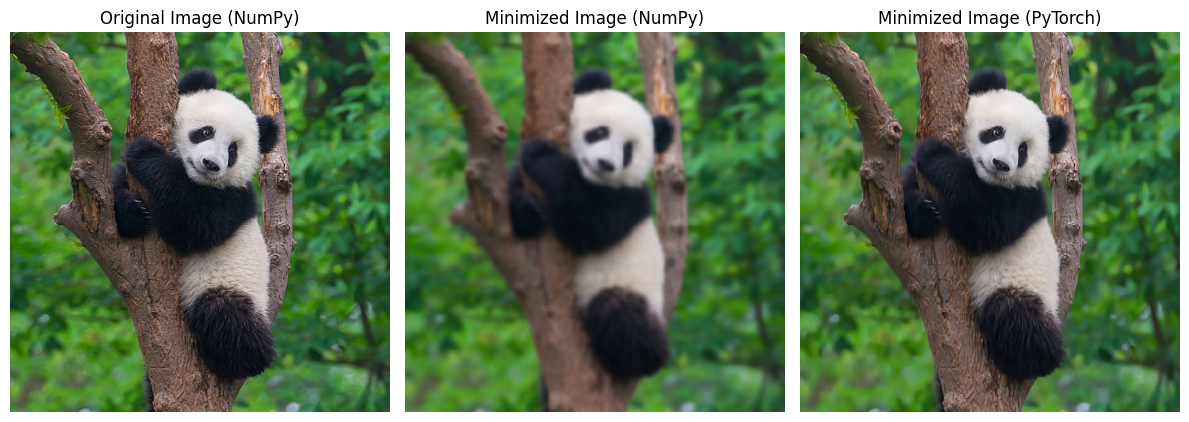

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.imshow(x_array[0])
plt.title("Original Image (NumPy)")
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(x_cpu_minimized[0][0])
plt.title("Minimized Image (NumPy)")
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(x_gpu_minimized[0][0].transpose(1, 0, 2))
plt.title("Minimized Image (PyTorch)")
plt.axis('off')
plt.tight_layout()
plt.show()